In [1]:
#importing basic package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Read the file for indivudial assignment 

df_mentah = pd.read_csv("/Users/abdullahhasib/Documents/application file/NUS/courses/semester 2/SPH6004 Advanced Statistical Learning/group assignment/Assignment2_mimic dataset/MIMIC-IV-static(Group Assignment).csv")

df_mentah

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_los_hours,intime,outtime,los,deathtime,...,ck_mb_max,ggt_min,ggt_max,ld_ldh_min,ld_ldh_max,so2_min,so2_max,po2_min,po2_max,radiology_note_count
0,12466550,23998182,30000153,Trauma SICU (TSICU),Trauma SICU (TSICU),39.286111,2174-09-29 12:09:00,2174-10-01 03:26:10,1.636921,NaN,...,3.3,NaN,NaN,NaN,NaN,NaN,NaN,215.0,263.0,5
1,13180007,27543152,30000213,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),39.246667,2162-06-21 05:38:00,2162-06-22 20:52:48,1.635278,NaN,...,NaN,NaN,NaN,300.0,300.0,NaN,NaN,56.0,63.0,1
2,18421337,22413411,30000484,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),59.493333,2136-01-14 17:23:32,2136-01-17 04:53:08,2.478889,NaN,...,NaN,NaN,NaN,419.0,419.0,NaN,NaN,21.0,21.0,5
3,12207593,22795209,30000646,Coronary Care Unit (CCU),Coronary Care Unit (CCU),112.740556,2194-04-29 01:39:22,2194-05-03 18:23:48,4.697523,2194-05-06 02:29:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.0,71.0,5
4,12980335,23552849,30001148,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),27.243056,2156-08-30 11:10:59,2156-08-31 14:25:34,1.135127,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.0,170.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76938,16180713,20178444,39999301,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),27.525833,2111-08-18 15:47:00,2111-08-19 19:18:33,1.146910,2111-08-19 15:00:00,...,NaN,NaN,NaN,175.0,175.0,NaN,NaN,68.0,320.0,1
76939,15498623,27161460,39999384,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),30.618333,2158-05-24 19:50:01,2158-05-26 02:27:07,1.275764,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
76940,11256534,26910235,39999552,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),28.022778,2186-07-17 14:27:43,2186-07-18 18:29:05,1.167616,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,137.0,343.0,2
76941,15403458,25335698,39999562,Neuro Intermediate,Neuro Intermediate,119.911111,2129-01-24 17:24:09,2129-01-29 17:18:49,4.996296,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [5]:
###Acknowledgement to https://github.com/galuhsahid/data-preparation-with-python/blob/master/02_DataPreparationWithPython.ipynb
#dropping irrelevant categorical data

df_mentah.dtypes.head(50)

subject_id                        int64
hadm_id                           int64
stay_id                           int64
first_careunit                   object
last_careunit                    object
icu_los_hours                   float64
intime                           object
outtime                          object
los                             float64
deathtime                        object
icu_death_flag                    int64
insurance                        object
language                         object
race                             object
marital_status                   object
hospital_expire_flag              int64
age                               int64
gender                           object
sofa2_respiration_24h_max       float64
sofa2_cardiovascular_24h_max    float64
sofa2_coagulation_24h_max       float64
sofa2_liver_24h_max             float64
sofa2_renal_24h_max             float64
sofa2_cns_24h_max               float64
heart_rate_min                  float64


In [6]:
df_mentah.dtypes.head(100).index

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'icu_los_hours', 'intime', 'outtime', 'los', 'deathtime',
       'icu_death_flag', 'insurance', 'language', 'race', 'marital_status',
       'hospital_expire_flag', 'age', 'gender', 'sofa2_respiration_24h_max',
       'sofa2_cardiovascular_24h_max', 'sofa2_coagulation_24h_max',
       'sofa2_liver_24h_max', 'sofa2_renal_24h_max', 'sofa2_cns_24h_max',
       'heart_rate_min', 'heart_rate_max', 'heart_rate_mean', 'sbp_min',
       'sbp_max', 'sbp_mean', 'dbp_min', 'dbp_max', 'dbp_mean', 'mbp_min',
       'mbp_max', 'mbp_mean', 'resp_rate_min', 'resp_rate_max',
       'resp_rate_mean', 'temperature_min', 'temperature_max',
       'temperature_mean', 'spo2_min', 'spo2_max', 'spo2_mean', 'glucose_min',
       'glucose_max', 'glucose_mean', 'gcs_min', 'gcs_motor', 'gcs_verbal',
       'gcs_eyes', 'gcs_unable', 'hematocrit_min', 'hematocrit_max',
       'hemoglobin_min', 'hemoglobin_max', 'platelets_min', 'pl

In [7]:
df_drop_cat = df_mentah.drop(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'deathtime','insurance',
       'language', 'marital_status', 'hospital_expire_flag',], axis=1)

df_drop_cat

,icu_los_hours,los,icu_death_flag,race,age,gender,sofa2_respiration_24h_max,sofa2_cardiovascular_24h_max,sofa2_coagulation_24h_max,sofa2_liver_24h_max,...,ck_mb_max,ggt_min,ggt_max,ld_ldh_min,ld_ldh_max,so2_min,so2_max,po2_min,po2_max,radiology_note_count
0,39.286111,1.636921,0,WHITE,61,M,0.0,0.0,0.0,NaN,...,3.3,NaN,NaN,NaN,NaN,NaN,NaN,215.0,263.0,5
1,39.246667,1.635278,0,HISPANIC/LATINO - PUERTO RICAN,66,M,NaN,1.0,0.0,0.0,...,NaN,NaN,NaN,300.0,300.0,NaN,NaN,56.0,63.0,1
2,59.493333,2.478889,0,MULTIPLE RACE/ETHNICITY,92,M,NaN,3.0,0.0,0.0,...,NaN,NaN,NaN,419.0,419.0,NaN,NaN,21.0,21.0,5
3,112.740556,4.697523,0,ASIAN - CHINESE,44,M,2.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.0,71.0,5
4,27.243056,1.135127,0,UNABLE TO OBTAIN,68,M,1.0,1.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.0,170.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76938,27.525833,1.146910,1,BLACK/AFRICAN AMERICAN,77,M,NaN,0.0,1.0,0.0,...,NaN,NaN,NaN,175.0,175.0,NaN,NaN,68.0,320.0,1
76939,30.618333,1.275764,0,WHITE,81,F,NaN,1.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
76940,28.022778,1.167616,0,WHITE,72,F,3.0,1.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,137.0,343.0,2
76941,119.911111,4.996296,0,WHITE,71,M,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [8]:
df_drop_cat.dtypes.head(100).index

Index(['icu_los_hours', 'los', 'icu_death_flag', 'race', 'age', 'gender',
       'sofa2_respiration_24h_max', 'sofa2_cardiovascular_24h_max',
       'sofa2_coagulation_24h_max', 'sofa2_liver_24h_max',
       'sofa2_renal_24h_max', 'sofa2_cns_24h_max', 'heart_rate_min',
       'heart_rate_max', 'heart_rate_mean', 'sbp_min', 'sbp_max', 'sbp_mean',
       'dbp_min', 'dbp_max', 'dbp_mean', 'mbp_min', 'mbp_max', 'mbp_mean',
       'resp_rate_min', 'resp_rate_max', 'resp_rate_mean', 'temperature_min',
       'temperature_max', 'temperature_mean', 'spo2_min', 'spo2_max',
       'spo2_mean', 'glucose_min', 'glucose_max', 'glucose_mean', 'gcs_min',
       'gcs_motor', 'gcs_verbal', 'gcs_eyes', 'gcs_unable', 'hematocrit_min',
       'hematocrit_max', 'hemoglobin_min', 'hemoglobin_max', 'platelets_min',
       'platelets_max', 'wbc_min', 'wbc_max', 'albumin_min', 'albumin_max',
       'globulin_min', 'globulin_max', 'total_protein_min',
       'total_protein_max', 'aniongap_min', 'aniongap_max', 

In [9]:
###Acknowledgement to pandas cheat sheet https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf
#identification of column with missing values

df_drop_cat.isnull().sum().sort_values(ascending=False).head(50)

inr_min                   76943
ast_max                   76943
so2_max                   76943
so2_min                   76943
inr_max                   76943
ast_min                   76943
nrbc_min                  76906
nrbc_max                  76906
d_dimer_min               76399
d_dimer_max               76399
ggt_max                   76395
ggt_min                   76395
globulin_max              75451
globulin_min              75451
bilirubin_indirect_max    74539
bilirubin_indirect_min    74539
total_protein_max         74527
total_protein_min         74527
bilirubin_direct_max      74418
bilirubin_direct_min      74418
amylase_max               72444
amylase_min               72444
ck_mb_min                 72125
ck_mb_max                 72125
atyps_min                 70670
atyps_max                 70670
metas_max                 70645
metas_min                 70645
bands_min                 70166
bands_max                 70166
imm_granulocytes_min      67907
imm_gran

In [10]:
#dropping columns with high missing values

df_drop_cat.isnull().sum().sort_values(ascending=False).head(50).index

Index(['inr_min', 'ast_max', 'so2_max', 'so2_min', 'inr_max', 'ast_min',
       'nrbc_min', 'nrbc_max', 'd_dimer_min', 'd_dimer_max', 'ggt_max',
       'ggt_min', 'globulin_max', 'globulin_min', 'bilirubin_indirect_max',
       'bilirubin_indirect_min', 'total_protein_max', 'total_protein_min',
       'bilirubin_direct_max', 'bilirubin_direct_min', 'amylase_max',
       'amylase_min', 'ck_mb_min', 'ck_mb_max', 'atyps_min', 'atyps_max',
       'metas_max', 'metas_min', 'bands_min', 'bands_max',
       'imm_granulocytes_min', 'imm_granulocytes_max', 'abs_monocytes_min',
       'abs_monocytes_max', 'abs_neutrophils_min', 'abs_neutrophils_max',
       'abs_basophils_max', 'abs_basophils_min', 'abs_eosinophils_min',
       'abs_eosinophils_max', 'abs_lymphocytes_min', 'abs_lymphocytes_max',
       'fibrinogen_max', 'fibrinogen_min', 'albumin_min', 'albumin_max',
       'ld_ldh_max', 'ld_ldh_min', 'ck_cpk_max', 'ck_cpk_min'],
      dtype='object')

In [11]:
df_drop_head50 = df_drop_cat.isnull().sum().sort_values(ascending=False).head(50).index

df_drop_1 = df_drop_cat.drop(columns = df_drop_head50)

df_drop_1

,icu_los_hours,los,icu_death_flag,race,age,gender,sofa2_respiration_24h_max,sofa2_cardiovascular_24h_max,sofa2_coagulation_24h_max,sofa2_liver_24h_max,...,ptt_max,alt_min,alt_max,alp_min,alp_max,bilirubin_total_min,bilirubin_total_max,po2_min,po2_max,radiology_note_count
0,39.286111,1.636921,0,WHITE,61,M,0.0,0.0,0.0,NaN,...,25.3,NaN,NaN,NaN,NaN,NaN,NaN,215.0,263.0,5
1,39.246667,1.635278,0,HISPANIC/LATINO - PUERTO RICAN,66,M,NaN,1.0,0.0,0.0,...,NaN,12.0,12.0,97.0,97.0,0.3,0.3,56.0,63.0,1
2,59.493333,2.478889,0,MULTIPLE RACE/ETHNICITY,92,M,NaN,3.0,0.0,0.0,...,36.1,15.0,15.0,78.0,78.0,0.3,0.3,21.0,21.0,5
3,112.740556,4.697523,0,ASIAN - CHINESE,44,M,2.0,1.0,0.0,0.0,...,37.4,22.0,22.0,97.0,97.0,0.7,0.7,71.0,71.0,5
4,27.243056,1.135127,0,UNABLE TO OBTAIN,68,M,1.0,1.0,0.0,NaN,...,29.5,NaN,NaN,NaN,NaN,NaN,NaN,107.0,170.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76938,27.525833,1.146910,1,BLACK/AFRICAN AMERICAN,77,M,NaN,0.0,1.0,0.0,...,34.7,13.0,13.0,59.0,59.0,0.4,0.4,68.0,320.0,1
76939,30.618333,1.275764,0,WHITE,81,F,NaN,1.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
76940,28.022778,1.167616,0,WHITE,72,F,3.0,1.0,0.0,NaN,...,29.4,NaN,NaN,NaN,NaN,NaN,NaN,137.0,343.0,2
76941,119.911111,4.996296,0,WHITE,71,M,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [14]:
#second round for dropping column with missing values

# as the row is 76,943 rows, that means the treshold 50% will be >= 38471.5 so that any misisng values above this number will be removed

df_drop_1.isnull().sum().sort_values(ascending=False).head(50)

sofa2_respiration_24h_max    51883
sofa2_liver_24h_max          47688
alp_max                      45667
alp_min                      45667
bilirubin_total_max          45589
bilirubin_total_min          45589
alt_min                      45408
alt_max                      45408
po2_min                      36167
po2_max                      36167
ptt_max                      15715
ptt_min                      15715
thrombin_max                 15715
thrombin_min                 15715
pt_max                       15116
pt_min                       15116
sofa2_coagulation_24h_max     5107
sofa2_renal_24h_max           3862
calcium_min                   3536
calcium_max                   3536
platelets_min                 2804
platelets_max                 2804
hemoglobin_min                2697
hemoglobin_max                2697
wbc_min                       2648
wbc_max                       2648
hematocrit_max                2545
hematocrit_min                2545
temperature_min     

In [16]:
df_drop_1.isnull().sum().sort_values(ascending=False).head(50).index

Index(['sofa2_respiration_24h_max', 'sofa2_liver_24h_max', 'alp_max',
       'alp_min', 'bilirubin_total_max', 'bilirubin_total_min', 'alt_min',
       'alt_max', 'po2_min', 'po2_max', 'ptt_max', 'ptt_min', 'thrombin_max',
       'thrombin_min', 'pt_max', 'pt_min', 'sofa2_coagulation_24h_max',
       'sofa2_renal_24h_max', 'calcium_min', 'calcium_max', 'platelets_min',
       'platelets_max', 'hemoglobin_min', 'hemoglobin_max', 'wbc_min',
       'wbc_max', 'hematocrit_max', 'hematocrit_min', 'temperature_min',
       'temperature_max', 'temperature_mean', 'aniongap_min', 'aniongap_max',
       'bun_min', 'bun_max', 'bicarbonate_max', 'bicarbonate_min',
       'creatinine_min', 'creatinine_max', 'chloride_min', 'chloride_max',
       'sodium_max', 'sodium_min', 'potassium_min', 'potassium_max',
       'glucose_mean', 'glucose_max', 'glucose_min', 'sofa2_cns_24h_max',
       'gcs_motor'],
      dtype='object')

In [17]:
df_drop_2 = df_drop_1.drop(['sofa2_respiration_24h_max', 'sofa2_liver_24h_max', 'alp_max',
       'alp_min', 'bilirubin_total_max', 'bilirubin_total_min', 'alt_min',
       'alt_max'], axis=1)

df_drop_2

,icu_los_hours,los,icu_death_flag,race,age,gender,sofa2_cardiovascular_24h_max,sofa2_coagulation_24h_max,sofa2_renal_24h_max,sofa2_cns_24h_max,...,potassium_max,thrombin_min,thrombin_max,pt_min,pt_max,ptt_min,ptt_max,po2_min,po2_max,radiology_note_count
0,39.286111,1.636921,0,WHITE,61,M,0.0,0.0,0.0,3.0,...,4.8,25.3,25.3,13.2,13.2,25.3,25.3,215.0,263.0,5
1,39.246667,1.635278,0,HISPANIC/LATINO - PUERTO RICAN,66,M,1.0,0.0,3.0,1.0,...,4.9,NaN,NaN,NaN,NaN,NaN,NaN,56.0,63.0,1
2,59.493333,2.478889,0,MULTIPLE RACE/ETHNICITY,92,M,3.0,0.0,1.0,4.0,...,5.4,36.1,36.1,16.2,16.2,36.1,36.1,21.0,21.0,5
3,112.740556,4.697523,0,ASIAN - CHINESE,44,M,1.0,0.0,0.0,0.0,...,4.2,35.3,37.4,14.3,14.5,35.3,37.4,71.0,71.0,5
4,27.243056,1.135127,0,UNABLE TO OBTAIN,68,M,1.0,0.0,0.0,4.0,...,6.3,27.3,29.5,13.6,14.9,27.3,29.5,107.0,170.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76938,27.525833,1.146910,1,BLACK/AFRICAN AMERICAN,77,M,0.0,1.0,1.0,0.0,...,4.3,26.5,34.7,13.4,16.1,26.5,34.7,68.0,320.0,1
76939,30.618333,1.275764,0,WHITE,81,F,1.0,0.0,2.0,0.0,...,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
76940,28.022778,1.167616,0,WHITE,72,F,1.0,0.0,0.0,4.0,...,6.4,26.5,29.4,12.3,16.6,26.5,29.4,137.0,343.0,2
76941,119.911111,4.996296,0,WHITE,71,M,0.0,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [18]:
###Acknowledgement to https://github.com/galuhsahid/data-preparation-with-python/blob/master/01_DataPreparationWithPython.ipynb
#changing race into different categorical (one hot)

#identifying values in the column race
race = df_drop_2['race'].unique()

race

array(['WHITE', 'HISPANIC/LATINO - PUERTO RICAN',
       'MULTIPLE RACE/ETHNICITY', 'ASIAN - CHINESE', 'UNABLE TO OBTAIN',
       'UNKNOWN', 'HISPANIC/LATINO - SALVADORAN',
       'BLACK/AFRICAN AMERICAN', 'WHITE - OTHER EUROPEAN',
       'BLACK/CARIBBEAN ISLAND', 'ASIAN - SOUTH EAST ASIAN',
       'BLACK/CAPE VERDEAN', 'ASIAN', 'BLACK/AFRICAN',
       'WHITE - EASTERN EUROPEAN', 'WHITE - RUSSIAN', 'OTHER',
       'PATIENT DECLINED TO ANSWER', 'HISPANIC OR LATINO',
       'HISPANIC/LATINO - HONDURAN', 'HISPANIC/LATINO - DOMINICAN',
       'SOUTH AMERICAN', 'PORTUGUESE', 'HISPANIC/LATINO - COLUMBIAN',
       'ASIAN - ASIAN INDIAN', 'HISPANIC/LATINO - CUBAN',
       'WHITE - BRAZILIAN', 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER',
       'AMERICAN INDIAN/ALASKA NATIVE',
       'HISPANIC/LATINO - CENTRAL AMERICAN', 'ASIAN - KOREAN',
       'HISPANIC/LATINO - GUATEMALAN', 'HISPANIC/LATINO - MEXICAN'],
      dtype=object)

In [19]:
#identifying how many values in the column race

race = df_drop_2['race'].nunique()

race

33

In [20]:
###https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.replace.html#pandas.DataFrame.replace
#Changing the race category

df_race = df_drop_2.replace(['ASIAN', 
                             'ASIAN - CHINESE',
                             'ASIAN - KOREAN', 
                             'ASIAN - ASIAN INDIAN',
                             'ASIAN - SOUTH EAST ASIAN'], 
                            'ASIAN').replace(['WHITE',
                            'WHITE - OTHER EUROPEAN',
                            'WHITE - BRAZILIAN',
                            'WHITE - EASTERN EUROPEAN',
                            'WHITE - RUSSIAN',
                            'HISPANIC/LATINO - MEXICAN', 
                            'HISPANIC OR LATINO',
                            'HISPANIC/LATINO - HONDURAN', 
                            'HISPANIC/LATINO - COLUMBIAN',
                            'HISPANIC/LATINO - CUBAN', 
                            'HISPANIC/LATINO - DOMINICAN',
                            'HISPANIC/LATINO - PUERTO RICAN', 
                            'HISPANIC/LATINO - SALVADORAN',
                            'HISPANIC/LATINO - CENTRAL AMERICAN', 
                            'HISPANIC/LATINO - GUATEMALAN',
                            'PORTUGUESE'], 
                            'CAUCASIAN').replace(['BLACK/AFRICAN AMERICAN', 
                            'BLACK/CAPE VERDEAN',
                            'BLACK/CARIBBEAN ISLAND',
                            'BLACK/AFRICAN'], 
                            'NEGROID').replace(['UNABLE TO OBTAIN', 
                            'MULTIPLE RACE/ETHNICITY', 
                            'PATIENT DECLINED TO ANSWER',
                            'AMERICAN INDIAN/ALASKA NATIVE', 
                            'OTHER', 
                            'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER',
                            'SOUTH AMERICAN', 
                            'UNKNOWN'], 
                            'OTHER')

df_race  

,icu_los_hours,los,icu_death_flag,race,age,gender,sofa2_cardiovascular_24h_max,sofa2_coagulation_24h_max,sofa2_renal_24h_max,sofa2_cns_24h_max,...,potassium_max,thrombin_min,thrombin_max,pt_min,pt_max,ptt_min,ptt_max,po2_min,po2_max,radiology_note_count
0,39.286111,1.636921,0,CAUCASIAN,61,M,0.0,0.0,0.0,3.0,...,4.8,25.3,25.3,13.2,13.2,25.3,25.3,215.0,263.0,5
1,39.246667,1.635278,0,CAUCASIAN,66,M,1.0,0.0,3.0,1.0,...,4.9,NaN,NaN,NaN,NaN,NaN,NaN,56.0,63.0,1
2,59.493333,2.478889,0,OTHER,92,M,3.0,0.0,1.0,4.0,...,5.4,36.1,36.1,16.2,16.2,36.1,36.1,21.0,21.0,5
3,112.740556,4.697523,0,ASIAN,44,M,1.0,0.0,0.0,0.0,...,4.2,35.3,37.4,14.3,14.5,35.3,37.4,71.0,71.0,5
4,27.243056,1.135127,0,OTHER,68,M,1.0,0.0,0.0,4.0,...,6.3,27.3,29.5,13.6,14.9,27.3,29.5,107.0,170.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76938,27.525833,1.146910,1,NEGROID,77,M,0.0,1.0,1.0,0.0,...,4.3,26.5,34.7,13.4,16.1,26.5,34.7,68.0,320.0,1
76939,30.618333,1.275764,0,CAUCASIAN,81,F,1.0,0.0,2.0,0.0,...,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
76940,28.022778,1.167616,0,CAUCASIAN,72,F,1.0,0.0,0.0,4.0,...,6.4,26.5,29.4,12.3,16.6,26.5,29.4,137.0,343.0,2
76941,119.911111,4.996296,0,CAUCASIAN,71,M,0.0,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [21]:
#checking the value for race
df_race['race'].unique()

array(['CAUCASIAN', 'OTHER', 'ASIAN', 'NEGROID'], dtype=object)

In [22]:
###Acknowledgement to https://github.com/galuhsahid/data-preparation-with-python/blob/master/01_DataPreparationWithPython.ipynb

df_race.head().transpose()

,0,1,2,3,4
icu_los_hours,39.286111,39.246667,59.493333,112.740556,27.243056
los,1.636921,1.635278,2.478889,4.697523,1.135127
icu_death_flag,0,0,0,0,0
race,CAUCASIAN,CAUCASIAN,OTHER,ASIAN,OTHER
age,61,66,92,44,68
...,...,...,...,...,...
ptt_min,25.3,NaN,36.1,35.3,27.3
ptt_max,25.3,NaN,36.1,37.4,29.5
po2_min,215.0,56.0,21.0,71.0,107.0
po2_max,263.0,63.0,21.0,71.0,170.0


In [23]:
df_race.isnull().sum().sort_values(ascending=True)

icu_los_hours               0
gender                      0
age                         0
radiology_note_count        0
icu_death_flag              0
                        ...  
thrombin_max            15715
ptt_min                 15715
ptt_max                 15715
po2_max                 36167
po2_min                 36167
Length: 72, dtype: int64

In [25]:
###Acknowledgement to https://www.youtube.com/watch?v=WWbyYFPHDH8&t=599s
#One Hot Encoding

onehot = df_race['race'].values.reshape(-1,1)
onehot

array([['CAUCASIAN'],
       ['CAUCASIAN'],
       ['OTHER'],
       ...,
       ['CAUCASIAN'],
       ['CAUCASIAN'],
       ['CAUCASIAN']], shape=(76943, 1), dtype=object)

In [26]:
from sklearn. preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder()

onehot = onehot_encoder.fit_transform(onehot).toarray()
onehot

array([[0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       ...,
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]], shape=(76943, 4))

In [27]:
onehot_encoder.categories_

[array(['ASIAN', 'CAUCASIAN', 'NEGROID', 'OTHER'], dtype=object)]

In [28]:
df_onehot = pd.DataFrame(onehot, columns=[str(i) for i in range(onehot.shape[1])])
df_onehot

,0,1,2,3
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0
...,...,...,...,...
76938,0.0,0.0,1.0,0.0
76939,0.0,1.0,0.0,0.0
76940,0.0,1.0,0.0,0.0
76941,0.0,1.0,0.0,0.0


In [29]:
df_onehot1 = pd.concat([df_onehot, df_race], axis=1)
df_onehot1

,0,1,2,3,icu_los_hours,los,icu_death_flag,race,age,gender,...,potassium_max,thrombin_min,thrombin_max,pt_min,pt_max,ptt_min,ptt_max,po2_min,po2_max,radiology_note_count
0,0.0,1.0,0.0,0.0,39.286111,1.636921,0,CAUCASIAN,61,M,...,4.8,25.3,25.3,13.2,13.2,25.3,25.3,215.0,263.0,5
1,0.0,1.0,0.0,0.0,39.246667,1.635278,0,CAUCASIAN,66,M,...,4.9,NaN,NaN,NaN,NaN,NaN,NaN,56.0,63.0,1
2,0.0,0.0,0.0,1.0,59.493333,2.478889,0,OTHER,92,M,...,5.4,36.1,36.1,16.2,16.2,36.1,36.1,21.0,21.0,5
3,1.0,0.0,0.0,0.0,112.740556,4.697523,0,ASIAN,44,M,...,4.2,35.3,37.4,14.3,14.5,35.3,37.4,71.0,71.0,5
4,0.0,0.0,0.0,1.0,27.243056,1.135127,0,OTHER,68,M,...,6.3,27.3,29.5,13.6,14.9,27.3,29.5,107.0,170.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76938,0.0,0.0,1.0,0.0,27.525833,1.146910,1,NEGROID,77,M,...,4.3,26.5,34.7,13.4,16.1,26.5,34.7,68.0,320.0,1
76939,0.0,1.0,0.0,0.0,30.618333,1.275764,0,CAUCASIAN,81,F,...,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
76940,0.0,1.0,0.0,0.0,28.022778,1.167616,0,CAUCASIAN,72,F,...,6.4,26.5,29.4,12.3,16.6,26.5,29.4,137.0,343.0,2
76941,0.0,1.0,0.0,0.0,119.911111,4.996296,0,CAUCASIAN,71,M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [30]:
#Dropping race column

df_onehot2 = df_onehot1.drop(['race'], axis=1)

df_onehot2

,0,1,2,3,icu_los_hours,los,icu_death_flag,age,gender,sofa2_cardiovascular_24h_max,...,potassium_max,thrombin_min,thrombin_max,pt_min,pt_max,ptt_min,ptt_max,po2_min,po2_max,radiology_note_count
0,0.0,1.0,0.0,0.0,39.286111,1.636921,0,61,M,0.0,...,4.8,25.3,25.3,13.2,13.2,25.3,25.3,215.0,263.0,5
1,0.0,1.0,0.0,0.0,39.246667,1.635278,0,66,M,1.0,...,4.9,NaN,NaN,NaN,NaN,NaN,NaN,56.0,63.0,1
2,0.0,0.0,0.0,1.0,59.493333,2.478889,0,92,M,3.0,...,5.4,36.1,36.1,16.2,16.2,36.1,36.1,21.0,21.0,5
3,1.0,0.0,0.0,0.0,112.740556,4.697523,0,44,M,1.0,...,4.2,35.3,37.4,14.3,14.5,35.3,37.4,71.0,71.0,5
4,0.0,0.0,0.0,1.0,27.243056,1.135127,0,68,M,1.0,...,6.3,27.3,29.5,13.6,14.9,27.3,29.5,107.0,170.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76938,0.0,0.0,1.0,0.0,27.525833,1.146910,1,77,M,0.0,...,4.3,26.5,34.7,13.4,16.1,26.5,34.7,68.0,320.0,1
76939,0.0,1.0,0.0,0.0,30.618333,1.275764,0,81,F,1.0,...,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
76940,0.0,1.0,0.0,0.0,28.022778,1.167616,0,72,F,1.0,...,6.4,26.5,29.4,12.3,16.6,26.5,29.4,137.0,343.0,2
76941,0.0,1.0,0.0,0.0,119.911111,4.996296,0,71,M,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [31]:
#Changing the column name
df = df_onehot2.rename(columns = {'0':'ASIAN', '1':'CAUCASIAN', '2':'NEGROID', '3':'OTHER'})

df

,ASIAN,CAUCASIAN,NEGROID,OTHER,icu_los_hours,los,icu_death_flag,age,gender,sofa2_cardiovascular_24h_max,...,potassium_max,thrombin_min,thrombin_max,pt_min,pt_max,ptt_min,ptt_max,po2_min,po2_max,radiology_note_count
0,0.0,1.0,0.0,0.0,39.286111,1.636921,0,61,M,0.0,...,4.8,25.3,25.3,13.2,13.2,25.3,25.3,215.0,263.0,5
1,0.0,1.0,0.0,0.0,39.246667,1.635278,0,66,M,1.0,...,4.9,NaN,NaN,NaN,NaN,NaN,NaN,56.0,63.0,1
2,0.0,0.0,0.0,1.0,59.493333,2.478889,0,92,M,3.0,...,5.4,36.1,36.1,16.2,16.2,36.1,36.1,21.0,21.0,5
3,1.0,0.0,0.0,0.0,112.740556,4.697523,0,44,M,1.0,...,4.2,35.3,37.4,14.3,14.5,35.3,37.4,71.0,71.0,5
4,0.0,0.0,0.0,1.0,27.243056,1.135127,0,68,M,1.0,...,6.3,27.3,29.5,13.6,14.9,27.3,29.5,107.0,170.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76938,0.0,0.0,1.0,0.0,27.525833,1.146910,1,77,M,0.0,...,4.3,26.5,34.7,13.4,16.1,26.5,34.7,68.0,320.0,1
76939,0.0,1.0,0.0,0.0,30.618333,1.275764,0,81,F,1.0,...,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
76940,0.0,1.0,0.0,0.0,28.022778,1.167616,0,72,F,1.0,...,6.4,26.5,29.4,12.3,16.6,26.5,29.4,137.0,343.0,2
76941,0.0,1.0,0.0,0.0,119.911111,4.996296,0,71,M,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [32]:
###Acknowledgement to https://www.youtube.com/watch?v=WWbyYFPHDH8&t=539s
#Labelling gender

from sklearn.preprocessing import LabelEncoder

le_df = LabelEncoder()
df['gender'] = le_df.fit_transform(df['gender'])

df

,ASIAN,CAUCASIAN,NEGROID,OTHER,icu_los_hours,los,icu_death_flag,age,gender,sofa2_cardiovascular_24h_max,...,potassium_max,thrombin_min,thrombin_max,pt_min,pt_max,ptt_min,ptt_max,po2_min,po2_max,radiology_note_count
0,0.0,1.0,0.0,0.0,39.286111,1.636921,0,61,1,0.0,...,4.8,25.3,25.3,13.2,13.2,25.3,25.3,215.0,263.0,5
1,0.0,1.0,0.0,0.0,39.246667,1.635278,0,66,1,1.0,...,4.9,NaN,NaN,NaN,NaN,NaN,NaN,56.0,63.0,1
2,0.0,0.0,0.0,1.0,59.493333,2.478889,0,92,1,3.0,...,5.4,36.1,36.1,16.2,16.2,36.1,36.1,21.0,21.0,5
3,1.0,0.0,0.0,0.0,112.740556,4.697523,0,44,1,1.0,...,4.2,35.3,37.4,14.3,14.5,35.3,37.4,71.0,71.0,5
4,0.0,0.0,0.0,1.0,27.243056,1.135127,0,68,1,1.0,...,6.3,27.3,29.5,13.6,14.9,27.3,29.5,107.0,170.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76938,0.0,0.0,1.0,0.0,27.525833,1.146910,1,77,1,0.0,...,4.3,26.5,34.7,13.4,16.1,26.5,34.7,68.0,320.0,1
76939,0.0,1.0,0.0,0.0,30.618333,1.275764,0,81,0,1.0,...,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
76940,0.0,1.0,0.0,0.0,28.022778,1.167616,0,72,0,1.0,...,6.4,26.5,29.4,12.3,16.6,26.5,29.4,137.0,343.0,2
76941,0.0,1.0,0.0,0.0,119.911111,4.996296,0,71,1,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [33]:
### Acknowledgement to https://www.youtube.com/shorts/-OiRzEyvah0

#changing 1 to 0 and vice versa in icu_death_flag to avoid my confusiion. 1 is the discharge one and 0 is the death 

df['icu_death_flag'] = df['icu_death_flag'].replace({1:0, 0:1})
df

,ASIAN,CAUCASIAN,NEGROID,OTHER,icu_los_hours,los,icu_death_flag,age,gender,sofa2_cardiovascular_24h_max,...,potassium_max,thrombin_min,thrombin_max,pt_min,pt_max,ptt_min,ptt_max,po2_min,po2_max,radiology_note_count
0,0.0,1.0,0.0,0.0,39.286111,1.636921,1,61,1,0.0,...,4.8,25.3,25.3,13.2,13.2,25.3,25.3,215.0,263.0,5
1,0.0,1.0,0.0,0.0,39.246667,1.635278,1,66,1,1.0,...,4.9,NaN,NaN,NaN,NaN,NaN,NaN,56.0,63.0,1
2,0.0,0.0,0.0,1.0,59.493333,2.478889,1,92,1,3.0,...,5.4,36.1,36.1,16.2,16.2,36.1,36.1,21.0,21.0,5
3,1.0,0.0,0.0,0.0,112.740556,4.697523,1,44,1,1.0,...,4.2,35.3,37.4,14.3,14.5,35.3,37.4,71.0,71.0,5
4,0.0,0.0,0.0,1.0,27.243056,1.135127,1,68,1,1.0,...,6.3,27.3,29.5,13.6,14.9,27.3,29.5,107.0,170.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76938,0.0,0.0,1.0,0.0,27.525833,1.146910,0,77,1,0.0,...,4.3,26.5,34.7,13.4,16.1,26.5,34.7,68.0,320.0,1
76939,0.0,1.0,0.0,0.0,30.618333,1.275764,1,81,0,1.0,...,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
76940,0.0,1.0,0.0,0.0,28.022778,1.167616,1,72,0,1.0,...,6.4,26.5,29.4,12.3,16.6,26.5,29.4,137.0,343.0,2
76941,0.0,1.0,0.0,0.0,119.911111,4.996296,1,71,1,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


array([[<Axes: title={'center': 'ASIAN'}>,
        <Axes: title={'center': 'CAUCASIAN'}>,
        <Axes: title={'center': 'NEGROID'}>,
        <Axes: title={'center': 'OTHER'}>,
        <Axes: title={'center': 'icu_los_hours'}>,
        <Axes: title={'center': 'los'}>,
        <Axes: title={'center': 'icu_death_flag'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'gender'}>],
       [<Axes: title={'center': 'sofa2_cardiovascular_24h_max'}>,
        <Axes: title={'center': 'sofa2_coagulation_24h_max'}>,
        <Axes: title={'center': 'sofa2_renal_24h_max'}>,
        <Axes: title={'center': 'sofa2_cns_24h_max'}>,
        <Axes: title={'center': 'heart_rate_min'}>,
        <Axes: title={'center': 'heart_rate_max'}>,
        <Axes: title={'center': 'heart_rate_mean'}>,
        <Axes: title={'center': 'sbp_min'}>,
        <Axes: title={'center': 'sbp_max'}>],
       [<Axes: title={'center': 'sbp_mean'}>,
        <Axes: title={'center': 'dbp_min'}>,
        <Axe

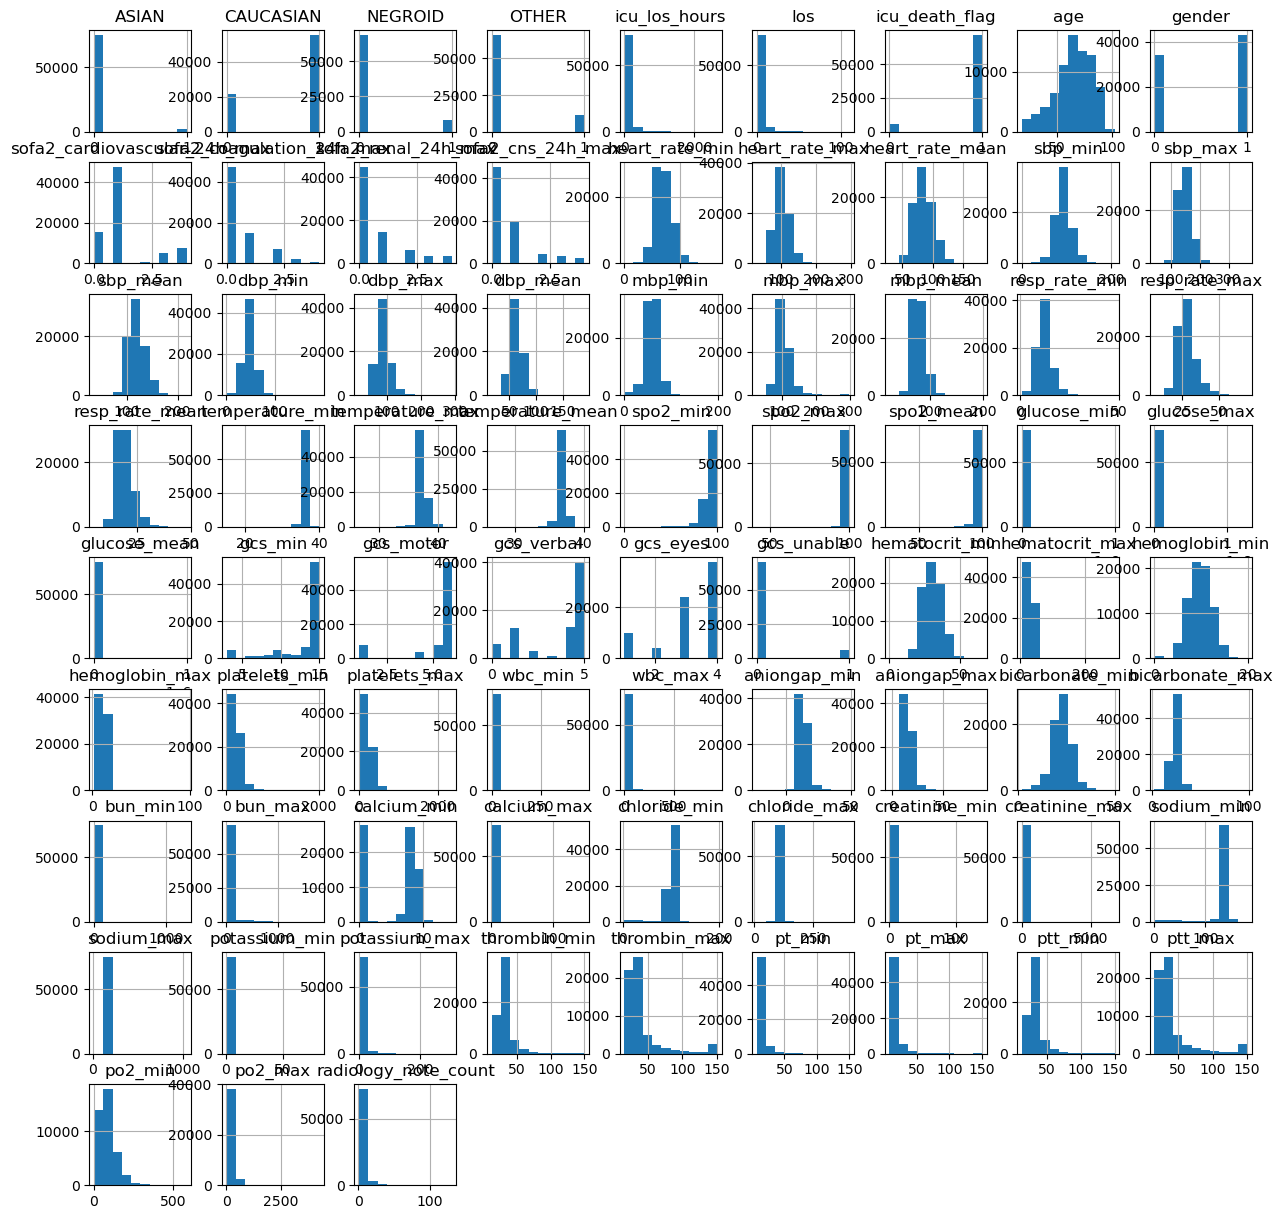

In [34]:
###Acknowledgement to https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html#pandas.DataFrame.hist
#Identification distribution of the data to see the skewness
df.hist(figsize=(15, 15))

In [35]:
###Acknowledgement to pandas cheat sheet https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf
#identification of column with missing values

df.isnull().sum().sort_values(ascending=False)

po2_max                 36167
po2_min                 36167
thrombin_min            15715
ptt_max                 15715
ptt_min                 15715
                        ...  
los                         0
icu_los_hours               0
OTHER                       0
NEGROID                     0
radiology_note_count        0
Length: 75, dtype: int64

In [36]:
#Filling the missing value with median

df = df.fillna(df.median())

In [33]:
#Sorting the value with missing value to check them

df.isnull().sum().sort_values(ascending=False)

ASIAN                           0
spo2_min                        0
mbp_max                         0
mbp_mean                        0
resp_rate_min                   0
resp_rate_max                   0
resp_rate_mean                  0
temperature_min                 0
temperature_max                 0
temperature_mean                0
spo2_max                        0
dbp_mean                        0
spo2_mean                       0
glucose_min                     0
glucose_max                     0
glucose_mean                    0
gcs_min                         0
gcs_motor                       0
gcs_verbal                      0
gcs_eyes                        0
mbp_min                         0
dbp_max                         0
CAUCASIAN                       0
sofa2_coagulation_24h_max       0
NEGROID                         0
OTHER                           0
los                             0
icu_death_flag                  0
age                             0
gender        

In [37]:
#Deciding which one is the target and which one is the features

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76943 entries, 0 to 76942
Data columns (total 75 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ASIAN                         76943 non-null  float64
 1   CAUCASIAN                     76943 non-null  float64
 2   NEGROID                       76943 non-null  float64
 3   OTHER                         76943 non-null  float64
 4   icu_los_hours                 76943 non-null  float64
 5   los                           76943 non-null  float64
 6   icu_death_flag                76943 non-null  int64  
 7   age                           76943 non-null  int64  
 8   gender                        76943 non-null  int64  
 9   sofa2_cardiovascular_24h_max  76943 non-null  float64
 10  sofa2_coagulation_24h_max     76943 non-null  float64
 11  sofa2_renal_24h_max           76943 non-null  float64
 12  sofa2_cns_24h_max             76943 non-null  float64
 13  h

In [55]:
y = df.iloc[:, 6]
x = df.drop(columns=['icu_death_flag'])

In [56]:
#checking the features 

x.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ASIAN,76943.0,0.029437,0.169030,0.00,0.000000,0.000000,0.000000,1.000000
CAUCASIAN,76943.0,0.718922,0.449528,0.00,0.000000,1.000000,1.000000,1.000000
NEGROID,76943.0,0.108626,0.311171,0.00,0.000000,0.000000,0.000000,1.000000
OTHER,76943.0,0.143015,0.350090,0.00,0.000000,0.000000,0.000000,1.000000
icu_los_hours,76943.0,82.846662,118.212433,0.03,26.003056,46.205833,89.069722,2645.574722
...,...,...,...,...,...,...,...,...
ptt_min,76943.0,32.658108,13.077463,12.60,27.200000,29.600000,32.900000,150.000000
ptt_max,76943.0,39.941653,25.685972,15.90,28.700000,31.700000,37.100000,150.000000
po2_min,76943.0,83.118529,42.474189,0.00,74.000000,77.000000,80.000000,587.000000
po2_max,76943.0,173.193052,102.526788,14.00,140.000000,151.000000,161.000000,4242.000000


In [57]:
#checking the target

y.describe()

count    76943.000000
mean         0.927037
std          0.260078
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: icu_death_flag, dtype: float64

In [58]:
# splitting the data

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=12)

In [59]:
#seeing my column

x_train.columns

Index(['ASIAN', 'CAUCASIAN', 'NEGROID', 'OTHER', 'icu_los_hours', 'los', 'age',
       'gender', 'sofa2_cardiovascular_24h_max', 'sofa2_coagulation_24h_max',
       'sofa2_renal_24h_max', 'sofa2_cns_24h_max', 'heart_rate_min',
       'heart_rate_max', 'heart_rate_mean', 'sbp_min', 'sbp_max', 'sbp_mean',
       'dbp_min', 'dbp_max', 'dbp_mean', 'mbp_min', 'mbp_max', 'mbp_mean',
       'resp_rate_min', 'resp_rate_max', 'resp_rate_mean', 'temperature_min',
       'temperature_max', 'temperature_mean', 'spo2_min', 'spo2_max',
       'spo2_mean', 'glucose_min', 'glucose_max', 'glucose_mean', 'gcs_min',
       'gcs_motor', 'gcs_verbal', 'gcs_eyes', 'gcs_unable', 'hematocrit_min',
       'hematocrit_max', 'hemoglobin_min', 'hemoglobin_max', 'platelets_min',
       'platelets_max', 'wbc_min', 'wbc_max', 'aniongap_min', 'aniongap_max',
       'bicarbonate_min', 'bicarbonate_max', 'bun_min', 'bun_max',
       'calcium_min', 'calcium_max', 'chloride_min', 'chloride_max',
       'creatinine_min', 

In [60]:
continuous_columns =['icu_los_hours', 'los', 'age', 'sofa2_cardiovascular_24h_max', 'sofa2_coagulation_24h_max',
       'sofa2_renal_24h_max', 'sofa2_cns_24h_max', 'heart_rate_min',
       'heart_rate_max', 'heart_rate_mean', 'sbp_min', 'sbp_max', 'sbp_mean',
       'dbp_min', 'dbp_max', 'dbp_mean', 'mbp_min', 'mbp_max', 'mbp_mean',
       'resp_rate_min', 'resp_rate_max', 'resp_rate_mean', 'temperature_min',
       'temperature_max', 'temperature_mean', 'spo2_min', 'spo2_max',
       'spo2_mean', 'glucose_min', 'glucose_max', 'glucose_mean', 'gcs_min',
       'gcs_motor', 'gcs_verbal', 'gcs_eyes', 'gcs_unable', 'hematocrit_min',
       'hematocrit_max', 'hemoglobin_min', 'hemoglobin_max', 'platelets_min',
       'platelets_max', 'wbc_min', 'wbc_max', 'aniongap_min', 'aniongap_max',
       'bicarbonate_min', 'bicarbonate_max', 'bun_min', 'bun_max',
       'calcium_min', 'calcium_max', 'chloride_min', 'chloride_max',
       'creatinine_min', 'creatinine_max', 'sodium_min', 'sodium_max',
       'potassium_min', 'potassium_max', 'thrombin_min', 'thrombin_max',
       'pt_min', 'pt_max', 'ptt_min', 'ptt_max', 'po2_min', 'po2_max',
       'radiology_note_count']

continuous_x_train = x_train[continuous_columns]

continuous_x_train

,icu_los_hours,los,age,sofa2_cardiovascular_24h_max,sofa2_coagulation_24h_max,sofa2_renal_24h_max,sofa2_cns_24h_max,heart_rate_min,heart_rate_max,heart_rate_mean,...,potassium_max,thrombin_min,thrombin_max,pt_min,pt_max,ptt_min,ptt_max,po2_min,po2_max,radiology_note_count
13954,26.138889,1.089120,66,1.0,1.0,0.0,0.0,73.0,100.0,89.620690,...,5.2,30.9,44.8,12.9,17.2,30.9,44.8,154.0,402.0,2
43921,93.016111,3.875671,82,1.0,0.0,0.0,0.0,67.0,112.0,93.809524,...,4.2,29.8,29.8,13.0,13.0,29.8,29.8,77.0,151.0,1
34614,15.935833,0.663993,51,4.0,3.0,2.0,0.0,86.0,121.0,101.461538,...,6.3,50.7,81.7,22.4,41.9,50.7,81.7,118.0,388.0,6
6714,73.238611,3.051609,87,4.0,1.0,4.0,0.0,58.0,257.0,92.520548,...,4.2,25.3,26.4,10.6,11.1,25.3,26.4,33.0,47.0,3
47812,159.059167,6.627465,66,4.0,1.0,4.0,3.0,82.0,135.0,108.560000,...,4.8,38.2,38.2,13.4,13.4,38.2,38.2,68.0,68.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61872,19.019167,0.792465,51,1.0,3.0,0.0,1.0,63.0,73.0,67.555556,...,4.3,34.7,34.7,12.5,12.5,34.7,34.7,77.0,151.0,1
75011,70.482500,2.936771,81,1.0,0.0,0.0,0.0,74.0,101.0,86.392857,...,3.6,29.6,31.7,10.5,10.5,29.6,31.7,77.0,151.0,2
36482,27.835000,1.159792,46,0.0,0.0,0.0,0.0,59.0,92.0,72.954545,...,3.4,29.6,31.7,13.4,14.3,29.6,31.7,77.0,151.0,1
40177,47.961389,1.998391,76,1.0,0.0,0.0,0.0,85.0,149.0,99.875000,...,3.9,31.4,150.0,20.0,20.0,31.4,150.0,123.0,493.0,2


In [61]:
categorical_column = ['ASIAN', 'CAUCASIAN', 'NEGROID', 'OTHER', 'gender']

categorical_x_train = x_train[categorical_column]

categorical_x_train

,ASIAN,CAUCASIAN,NEGROID,OTHER,gender
13954,0.0,0.0,0.0,1.0,1
43921,0.0,1.0,0.0,0.0,1
34614,0.0,1.0,0.0,0.0,1
6714,0.0,1.0,0.0,0.0,1
47812,0.0,0.0,1.0,0.0,1
...,...,...,...,...,...
61872,0.0,1.0,0.0,0.0,1
75011,0.0,0.0,0.0,1.0,1
36482,0.0,1.0,0.0,0.0,1
40177,0.0,1.0,0.0,0.0,1


In [62]:
#stand. the continuous data for the x train first

std_x_train_con = (continuous_x_train-continuous_x_train.mean())/continuous_x_train.std()
std_x_train_con.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
icu_los_hours,53860.0,3.614718e-17,1.0,-0.697502,-0.478481,-0.308338,0.051927,21.591826
los,53860.0,1.688627e-17,1.0,-0.697502,-0.478481,-0.308338,0.051927,21.591826
age,53860.0,2.817897e-16,1.0,-2.771600,-0.577506,0.074792,0.786390,2.209586
sofa2_cardiovascular_24h_max,53860.0,7.612016e-17,1.0,-1.076095,-0.199225,-0.199225,-0.199225,2.431385
sofa2_coagulation_24h_max,53860.0,3.218946e-17,1.0,-0.588309,-0.588309,-0.588309,0.622850,4.256327
...,...,...,...,...,...,...,...,...
ptt_min,53860.0,-2.437956e-16,1.0,-1.282175,-0.418999,-0.234033,0.020295,9.045104
ptt_max,53860.0,-5.540809e-18,1.0,-0.879991,-0.436441,-0.319717,-0.109614,4.283090
po2_min,53860.0,-4.802034e-17,1.0,-1.954733,-0.216216,-0.145735,-0.075255,11.835942
po2_max,53860.0,-9.287451e-17,1.0,-1.546445,-0.314594,-0.217597,-0.110902,39.463545


In [63]:
#collapsing the cat and con into one for x_train

std_x_train = pd.concat([categorical_x_train, std_x_train_con], axis=1)

std_x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53860 entries, 13954 to 19709
Data columns (total 74 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ASIAN                         53860 non-null  float64
 1   CAUCASIAN                     53860 non-null  float64
 2   NEGROID                       53860 non-null  float64
 3   OTHER                         53860 non-null  float64
 4   gender                        53860 non-null  int64  
 5   icu_los_hours                 53860 non-null  float64
 6   los                           53860 non-null  float64
 7   age                           53860 non-null  float64
 8   sofa2_cardiovascular_24h_max  53860 non-null  float64
 9   sofa2_coagulation_24h_max     53860 non-null  float64
 10  sofa2_renal_24h_max           53860 non-null  float64
 11  sofa2_cns_24h_max             53860 non-null  float64
 12  heart_rate_min                53860 non-null  float64
 13  he

In [64]:
continuous_x_test = x_test[continuous_columns]

continuous_x_test

,icu_los_hours,los,age,sofa2_cardiovascular_24h_max,sofa2_coagulation_24h_max,sofa2_renal_24h_max,sofa2_cns_24h_max,heart_rate_min,heart_rate_max,heart_rate_mean,...,potassium_max,thrombin_min,thrombin_max,pt_min,pt_max,ptt_min,ptt_max,po2_min,po2_max,radiology_note_count
21958,68.343611,2.847650,47,1.0,0.0,0.0,3.0,60.0,112.0,74.346154,...,4.2,29.6,31.7,13.4,14.3,29.6,31.7,77.0,151.0,1
1305,31.154444,1.298102,71,1.0,0.0,0.0,0.0,66.0,109.0,84.360000,...,3.5,25.1,25.1,13.0,13.0,25.1,25.1,106.0,163.0,1
51077,15.983333,0.665972,73,1.0,0.0,2.0,0.0,75.0,88.0,83.000000,...,4.9,24.7,24.7,12.0,12.0,24.7,24.7,77.0,151.0,1
71100,195.636667,8.151528,67,1.0,0.0,2.0,0.0,70.0,109.0,79.880000,...,4.4,28.0,28.5,12.0,12.2,28.0,28.5,30.0,30.0,2
72927,52.321944,2.180081,63,4.0,0.0,0.0,0.0,102.0,125.0,112.476190,...,4.3,35.8,35.8,16.6,16.6,35.8,35.8,77.0,151.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,207.006111,8.625255,41,1.0,0.0,2.0,3.0,120.0,130.0,125.640000,...,3.9,32.6,32.6,12.7,13.0,32.6,32.6,34.0,34.0,12
50237,152.304167,6.346007,73,1.0,0.0,1.0,0.0,83.0,122.0,103.407407,...,4.2,63.8,98.0,15.8,16.4,63.8,98.0,91.0,91.0,8
57247,37.258333,1.552431,67,4.0,0.0,0.0,4.0,86.0,107.0,98.480000,...,5.2,30.0,30.0,13.8,13.8,30.0,30.0,46.0,46.0,1
455,30.708889,1.279537,74,1.0,0.0,0.0,0.0,53.0,74.0,63.696970,...,4.4,65.7,87.7,12.9,13.3,65.7,87.7,77.0,151.0,2


In [65]:
categorical_x_test = x_test[categorical_column]

categorical_x_test

,ASIAN,CAUCASIAN,NEGROID,OTHER,gender
21958,0.0,0.0,1.0,0.0,0
1305,0.0,1.0,0.0,0.0,1
51077,0.0,1.0,0.0,0.0,1
71100,0.0,1.0,0.0,0.0,1
72927,0.0,0.0,1.0,0.0,0
...,...,...,...,...,...
6403,0.0,0.0,0.0,1.0,1
50237,0.0,0.0,0.0,1.0,1
57247,0.0,1.0,0.0,0.0,0
455,0.0,0.0,1.0,0.0,1


In [66]:
###Acknowledgement to hands-on file sph6004
#stand. the continuous data for the x test now

std_x_test_con = (continuous_x_test-continuous_x_test.mean())/continuous_x_test.std()
std_x_test_con.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
icu_los_hours,23083.0,7.895603e-17,1.0,-0.707779,-0.486421,-0.313615,0.053992,17.946947
los,23083.0,2.585695e-17,1.0,-0.707779,-0.486421,-0.313615,0.053992,17.946947
age,23083.0,1.268222e-16,1.0,-2.745595,-0.618670,0.090305,0.740198,2.099067
sofa2_cardiovascular_24h_max,23083.0,-1.600668e-17,1.0,-1.071332,-0.199345,-0.199345,-0.199345,2.416616
sofa2_coagulation_24h_max,23083.0,-8.772893e-17,1.0,-0.590022,-0.590022,-0.590022,0.639061,4.326311
...,...,...,...,...,...,...,...,...
ptt_min,23083.0,6.371890e-17,1.0,-1.510433,-0.413747,-0.233470,0.014411,8.810430
ptt_max,23083.0,3.570721e-17,1.0,-0.939526,-0.440495,-0.323534,-0.109106,4.288608
po2_min,23083.0,7.510827e-17,1.0,-1.867429,-0.234749,-0.140101,-0.069115,11.430627
po2_max,23083.0,7.695520e-19,1.0,-1.557869,-0.342265,-0.213786,-0.114956,5.547983


In [67]:
#collapsing the cat and con into one for x_test

std_x_test = pd.concat([categorical_x_test, std_x_test_con], axis=1)

std_x_test

,ASIAN,CAUCASIAN,NEGROID,OTHER,gender,icu_los_hours,los,age,sofa2_cardiovascular_24h_max,sofa2_coagulation_24h_max,...,potassium_max,thrombin_min,thrombin_max,pt_min,pt_max,ptt_min,ptt_max,po2_min,po2_max,radiology_note_count
21958,0.0,0.0,1.0,0.0,0,-0.124356,-0.124356,-1.032239,-0.199345,-0.590022,...,-0.231719,-0.233470,-0.323534,-0.258380,-0.241152,-0.233470,-0.323534,-0.140101,-0.213786,-0.456538
1305,0.0,1.0,0.0,0.0,1,-0.441965,-0.441965,0.385711,-0.199345,-0.590022,...,-0.300680,-0.571490,-0.580847,-0.323188,-0.386996,-0.571490,-0.580847,0.546097,-0.095190,-0.456538
51077,0.0,1.0,0.0,0.0,1,-0.571531,-0.571531,0.503873,-0.199345,-0.590022,...,-0.162758,-0.601536,-0.596442,-0.485209,-0.499183,-0.601536,-0.596442,-0.140101,-0.213786,-0.456538
71100,0.0,1.0,0.0,0.0,1,0.962774,0.962774,0.149386,-0.199345,-0.590022,...,-0.212016,-0.353655,-0.448292,-0.485209,-0.476745,-0.353655,-0.448292,-1.252216,-1.409625,-0.301256
72927,0.0,0.0,1.0,0.0,0,-0.261186,-0.261186,-0.086939,2.416616,-0.590022,...,-0.221867,0.232245,-0.163688,0.260087,0.016878,0.232245,-0.163688,-0.140101,-0.213786,-0.145973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,0.0,0.0,0.0,1.0,1,1.059873,1.059873,-1.386726,-0.199345,-0.590022,...,-0.261274,-0.008124,-0.288446,-0.371794,-0.386996,-0.008124,-0.288446,-1.157568,-1.370093,1.251574
50237,0.0,0.0,0.0,1.0,1,0.592698,0.592698,0.503873,-0.199345,-0.590022,...,-0.231719,2.335478,2.261293,0.130470,-0.005560,2.335478,2.261293,0.191167,-0.806764,0.630442
57247,0.0,1.0,0.0,0.0,0,-0.389835,-0.389835,0.149386,2.416616,-0.590022,...,-0.133203,-0.203424,-0.389812,-0.193571,-0.297246,-0.203424,-0.389812,-0.873624,-1.251497,-0.456538
455,0.0,0.0,1.0,0.0,1,-0.445770,-0.445770,0.562955,-0.199345,-0.590022,...,-0.212016,2.478197,1.859729,-0.339390,-0.353340,2.478197,1.859729,-0.140101,-0.213786,-0.301256


In [68]:
#checking the balance of the data

y_train.value_counts()

icu_death_flag
1    49943
0     3917
Name: count, dtype: int64

In [69]:
###Acknowledgement to hands-on file sph6004

#SMOTE
from imblearn.over_sampling import SMOTE

smote_sampler = SMOTE(random_state=12,sampling_strategy='minority')
X_df_SMOTE, y_df_SMOTE = smote_sampler.fit_resample(std_x_train, y_train)

In [70]:
y_df_SMOTE.value_counts()

icu_death_flag
1    49943
0    49943
Name: count, dtype: int64

Index(['ASIAN', 'CAUCASIAN', 'NEGROID', 'OTHER', 'gender', 'icu_los_hours',
       'los', 'age', 'sofa2_cardiovascular_24h_max',
       'sofa2_coagulation_24h_max', 'sofa2_renal_24h_max', 'sofa2_cns_24h_max',
       'heart_rate_min', 'heart_rate_max', 'heart_rate_mean', 'sbp_min',
       'sbp_max', 'sbp_mean', 'dbp_min', 'dbp_max', 'dbp_mean', 'mbp_min',
       'mbp_max', 'mbp_mean', 'resp_rate_min', 'resp_rate_max',
       'resp_rate_mean', 'temperature_min', 'temperature_max',
       'temperature_mean', 'spo2_min', 'spo2_max', 'spo2_mean', 'glucose_min',
       'glucose_max', 'glucose_mean', 'gcs_min', 'gcs_motor', 'gcs_verbal',
       'gcs_eyes', 'gcs_unable', 'hematocrit_min', 'hematocrit_max',
       'hemoglobin_min', 'hemoglobin_max', 'platelets_min', 'platelets_max',
       'wbc_min', 'wbc_max', 'aniongap_min', 'aniongap_max', 'bicarbonate_min',
       'bicarbonate_max', 'bun_min', 'bun_max', 'calcium_min', 'calcium_max',
       'chloride_min', 'chloride_max', 'creatinine_min', 

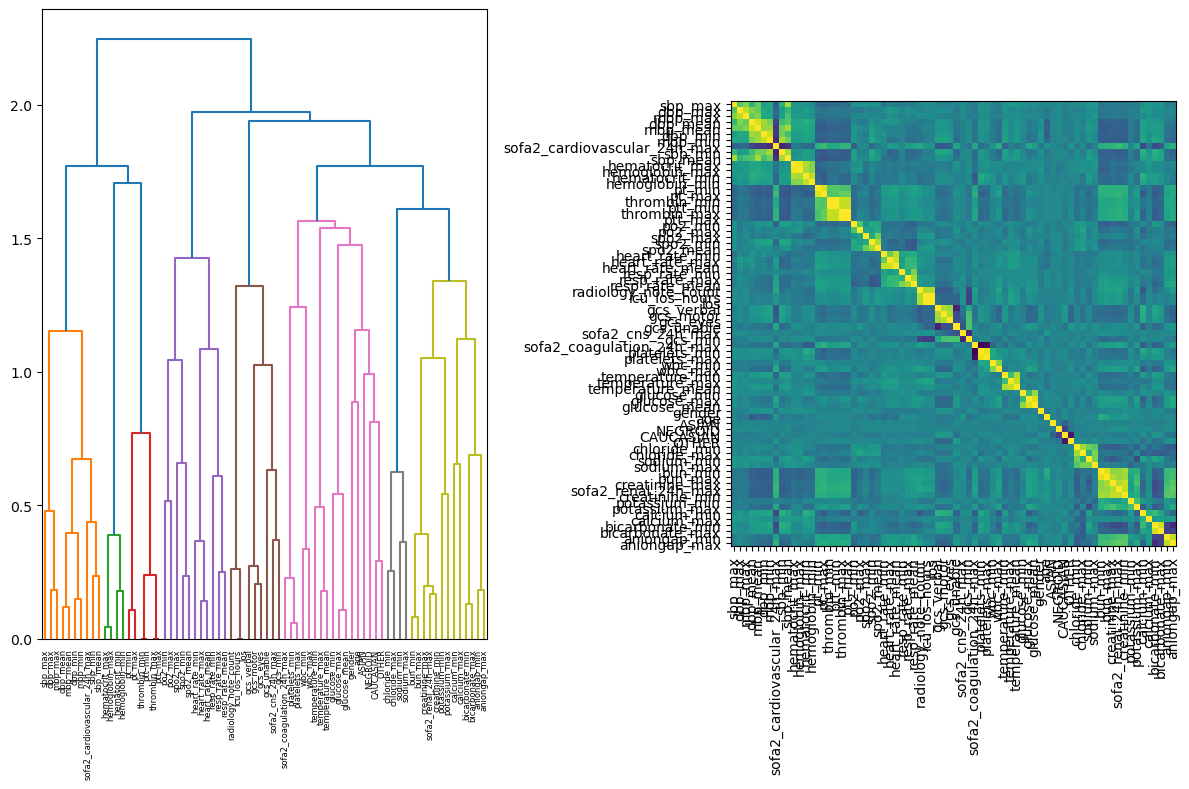

In [71]:
#Multicolinearity

###https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

X=X_df_SMOTE.copy() #untuk membuat duplikat supaya tidak terhubung dengan X_df_SMOTE_fw yg asal jika variabel asal dirubah

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
corr = spearmanr(X).correlation

# Ensure the correlation matrix is symmetric
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)

# We convert the correlation matrix to a distance matrix before performing
# hierarchical clustering using Ward's linkage.
distance_matrix = 1 - np.abs(corr)
dist_linkage = hierarchy.ward(squareform(distance_matrix))
dendro = hierarchy.dendrogram(
    dist_linkage, labels=X.columns.to_list(), ax=ax1, leaf_rotation=90
)
dendro_idx = np.arange(0, len(dendro["ivl"]))

ax2.imshow(corr[dendro["leaves"], :][:, dendro["leaves"]])
ax2.set_xticks(dendro_idx)
ax2.set_yticks(dendro_idx)
ax2.set_xticklabels(dendro["ivl"], rotation="vertical")
ax2.set_yticklabels(dendro["ivl"])
_ = fig.tight_layout()

print(X.columns)

In [78]:
###Acknowledgment to https://github.com/tempse/sklearn-beginners-template/blob/8f4509631b8ef29bb10dc4a827c2043fa73aadd7/example%20analysis%20-%20random%20forest.ipynb

#Training the Model (RFC) with full features

from sklearn.ensemble import RandomForestClassifier

model_RFC_full = RandomForestClassifier(n_estimators=500,
                             criterion='gini',
                             max_depth=None,
                             min_samples_split=1000,
                             min_samples_leaf=1,
                             min_weight_fraction_leaf=0.0,
                             max_features='sqrt',
                             max_leaf_nodes=None,
                             min_impurity_decrease=0.0,
                             bootstrap=True,
                             oob_score=False,
                             n_jobs=-1,
                             random_state=None,
                             verbose=0,
                             warm_start=False,
                             class_weight=None)
model_RFC_full.fit(X_df_SMOTE, y_df_SMOTE)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,1000
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Feature ranking:
	1. gcs_motor 	(0.161591)
	2. gcs_eyes 	(0.145086)
	3. gcs_verbal 	(0.122841)
	4. sofa2_cardiovascular_24h_max 	(0.078200)
	5. gcs_min 	(0.046771)
	6. sofa2_renal_24h_max 	(0.034233)
	7. aniongap_max 	(0.032530)
	8. spo2_min 	(0.026484)
	9. radiology_note_count 	(0.023842)
	10. bun_min 	(0.023820)
	11. sbp_min 	(0.023445)
	12. bun_max 	(0.023432)
	13. po2_min 	(0.021165)
	14. aniongap_min 	(0.017673)
	15. creatinine_max 	(0.015024)
	16. gcs_unable 	(0.013734)
	17. po2_max 	(0.011692)
	18. sofa2_cns_24h_max 	(0.010906)
	19. resp_rate_mean 	(0.010161)
	20. mbp_min 	(0.009878)
	21. creatinine_min 	(0.009550)
	22. los 	(0.009215)
	23. spo2_mean 	(0.008736)
	24. OTHER 	(0.008331)
	25. icu_los_hours 	(0.008081)
	26. sbp_mean 	(0.007908)
	27. calcium_min 	(0.007777)
	28. CAUCASIAN 	(0.007594)
	29. bicarbonate_min 	(0.006928)
	30. pt_min 	(0.006767)
	31. NEGROID 	(0.005530)
	32. gender 	(0.005298)
	33. pt_max 	(0.004969)
	34. calcium_max 	(0.004711)
	35. resp_rate_max 	(0.0039

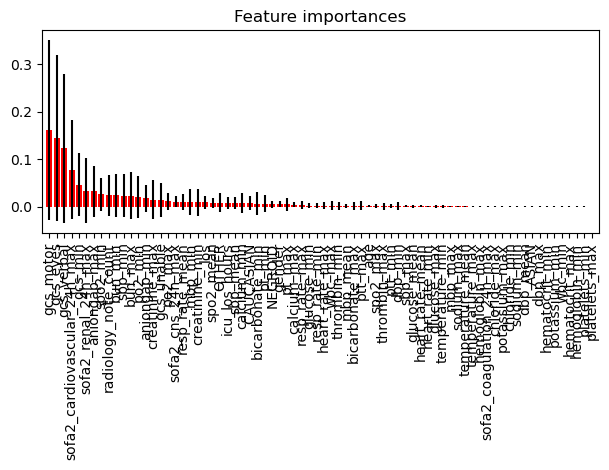

In [79]:
#Checking the features

importances = model_RFC_full.feature_importances_
std = np.std([tree.feature_importances_ for tree in model_RFC_full.estimators_],
             axis=0)
indices = np.argsort(importances)[::-1]
    
print("Feature ranking:")

featureNames = X_df_SMOTE.columns
    
for f in range(X_df_SMOTE.shape[1]):
    print("\t%d. %s \t(%f)" % (f + 1,
                               featureNames[indices[f]],
                               importances[indices[f]]))
    
plt.figure()
plt.title("Feature importances")
plt.bar(range(X_df_SMOTE.shape[1]),
        importances[indices],
        color="r",
        yerr=std[indices],
        align="center")
plt.xticks(range(X_df_SMOTE.shape[1]), featureNames[indices], rotation=90)
plt.xlim([-1, X_df_SMOTE.shape[1]])
plt.tight_layout()

In [91]:
###Acknowledgement to https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
estimator = RandomForestClassifier(max_depth=2, random_state=12)
selector = RFECV(estimator, step=1, cv=5, min_features_to_select=1)
selector = selector.fit(X_df_SMOTE, y_df_SMOTE)
selector.support_
selector.ranking_

array([2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [92]:
for i, col in zip(range(X_df_SMOTE.shape[1]), X_df_SMOTE.columns):
    print(f"{col} selected={selector.support_[i]} rank={selector.ranking_[i]}")

ASIAN selected=False rank=2
CAUCASIAN selected=True rank=1
NEGROID selected=True rank=1
OTHER selected=True rank=1
gender selected=True rank=1
icu_los_hours selected=True rank=1
los selected=True rank=1
age selected=True rank=1
sofa2_cardiovascular_24h_max selected=True rank=1
sofa2_coagulation_24h_max selected=True rank=1
sofa2_renal_24h_max selected=True rank=1
sofa2_cns_24h_max selected=True rank=1
heart_rate_min selected=True rank=1
heart_rate_max selected=True rank=1
heart_rate_mean selected=True rank=1
sbp_min selected=True rank=1
sbp_max selected=True rank=1
sbp_mean selected=True rank=1
dbp_min selected=True rank=1
dbp_max selected=True rank=1
dbp_mean selected=True rank=1
mbp_min selected=True rank=1
mbp_max selected=True rank=1
mbp_mean selected=True rank=1
resp_rate_min selected=True rank=1
resp_rate_max selected=True rank=1
resp_rate_mean selected=True rank=1
temperature_min selected=True rank=1
temperature_max selected=True rank=1
temperature_mean selected=True rank=1
spo2

In [93]:
import pandas as pd

# 1. Masukkan hasil ke dalam DataFrame
# Pastikan std_x_train.columns adalah kolom yang sama dengan X_df_SMOTE
ranking_df = pd.DataFrame({
    'Feature_Name': X_df_SMOTE.columns,
    'Selected': selector.support_,
    'Ranking': selector.ranking_
})

# 2. Urutkan dari Ranking 1 hingga yang terakhir (74)
# Ranking 1 adalah fitur-fitur terbaik yang dipilih model
ranking_df_sorted = ranking_df.sort_values(by='Ranking').reset_index(drop=True)

# 3. Tampilkan semua baris agar Anda bisa melihat urutan 1-74
pd.set_option('display.max_rows', None)
print(ranking_df_sorted)

                    Feature_Name  Selected  Ranking
0                        gcs_min      True        1
1                bicarbonate_max      True        1
2                bicarbonate_min      True        1
3                   aniongap_max      True        1
4                   aniongap_min      True        1
5                        wbc_max      True        1
6                        wbc_min      True        1
7                        bun_min      True        1
8                  platelets_max      True        1
9                 hemoglobin_max      True        1
10                hemoglobin_min      True        1
11                hematocrit_max      True        1
12                hematocrit_min      True        1
13                    gcs_unable      True        1
14                      gcs_eyes      True        1
15                 platelets_min      True        1
16                       bun_max      True        1
17                   calcium_min      True        1
18          

In [94]:
#training the model
from sklearn.linear_model import LogisticRegression
model_log= LogisticRegression(random_state=12, penalty='l1', C=0.01, solver='saga', max_iter=1000) 
model_log.fit(X_df_SMOTE, y_df_SMOTE)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,12
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


Feature ranking (Logistic Regression Coefficients):
	1. gender 	(0.830472)
	2. gcs_eyes 	(0.593811)
	3. age 	(0.574442)
	4. gcs_verbal 	(0.461099)
	5. OTHER 	(0.412935)
	6. resp_rate_mean 	(0.357215)
	7. radiology_note_count 	(0.338937)
	8. heart_rate_mean 	(0.336837)
	9. sbp_mean 	(0.329891)
	10. po2_max 	(0.315547)
	11. sofa2_cns_24h_max 	(0.305115)
	12. sofa2_cardiovascular_24h_max 	(0.293555)
	13. gcs_motor 	(0.279353)
	14. hemoglobin_max 	(0.276458)
	15. aniongap_max 	(0.272701)
	16. calcium_max 	(0.271661)
	17. NEGROID 	(0.266072)
	18. gcs_min 	(0.248774)
	19. spo2_mean 	(0.244619)
	20. spo2_min 	(0.198382)
	21. sbp_max 	(0.196255)
	22. temperature_mean 	(0.181152)
	23. dbp_max 	(0.172248)
	24. aniongap_min 	(0.169198)
	25. dbp_mean 	(0.163214)
	26. heart_rate_min 	(0.154433)
	27. sbp_min 	(0.136747)
	28. hematocrit_min 	(0.130945)
	29. resp_rate_max 	(0.113964)
	30. gcs_unable 	(0.103281)
	31. bun_min 	(0.102965)
	32. po2_min 	(0.101983)
	33. icu_los_hours 	(0.093966)
	34. los 	

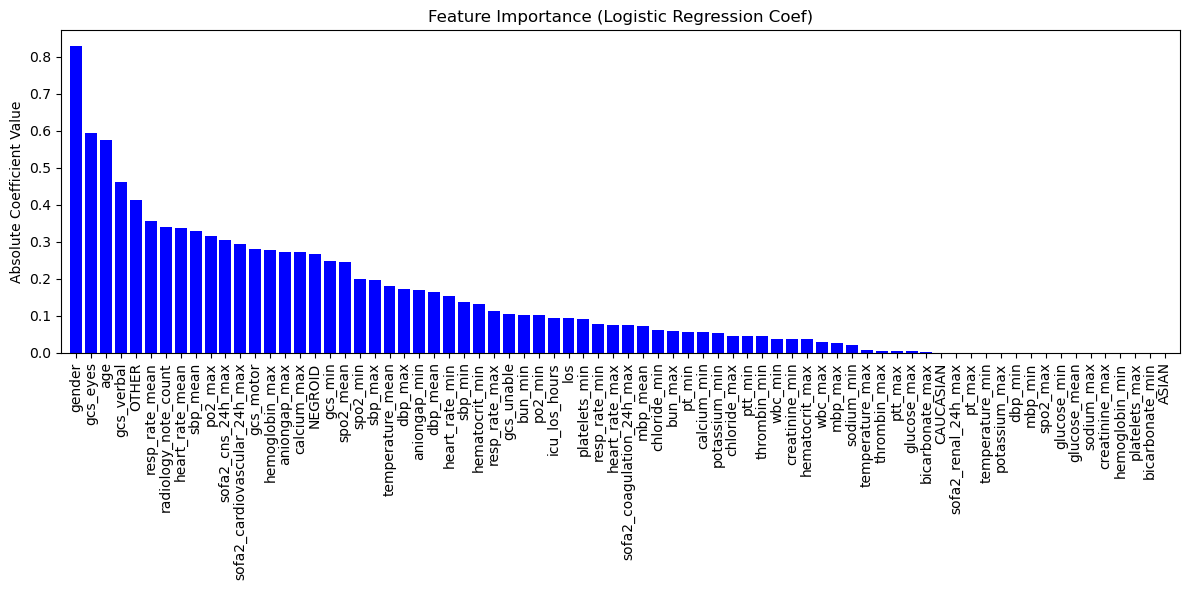

In [95]:
#Checking the features

import numpy as np
import matplotlib.pyplot as plt

# 1. Ambil koefisien (gunakan nilai absolut karena koefisien bisa negatif)
# .coef_[0] digunakan karena Logistic Regression mengembalikan array 2D
importances = np.abs(model_log.coef_[0])

# 2. Urutkan indeks dari yang terbesar ke terkecil
indices = np.argsort(importances)[::-1]

print("Feature ranking (Logistic Regression Coefficients):")

featureNames = X_df_SMOTE.columns

for f in range(X_df_SMOTE.shape[1]):
    print("\t%d. %s \t(%f)" % (f + 1, 
                               featureNames[indices[f]], 
                               importances[indices[f]]))

# 3. Visualisasi (Tanpa yerr/std karena model linear tidak memiliki variabilitas inter-tree)
plt.figure(figsize=(12, 6))
plt.title("Feature Importance (Logistic Regression Coef)")
plt.bar(range(X_df_SMOTE.shape[1]), 
        importances[indices], 
        color="b", 
        align="center")
plt.xticks(range(X_df_SMOTE.shape[1]), featureNames[indices], rotation=90)
plt.xlim([-1, X_df_SMOTE.shape[1]])
plt.ylabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()